In [1]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import Callback
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('healthy_posture_modeling.csv')
df.head()

,total_sitting_minutes,number_of_breaks,avg_break_duration_minutes,longest_sitting_streak_minutes,fatigue_level,age,daily_work_hours,bmi,sleep_hours,gender,work_type,fitness_level,day_of_week,time_of_day_dominant,device_preference,risk_level_encoded
0,340.238897,4,3.770013,221.437993,5.661973,19,10,19.924537,4.859519,0,1,1,4,1,1,2
1,395.020146,4,4.808095,291.764569,8.335067,45,5,16.257734,4.311717,0,2,2,0,1,1,2
2,201.821618,8,3.912248,163.409113,5.374609,23,5,17.856108,8.522519,0,0,1,5,0,1,0
3,326.624111,7,5.360238,261.811899,5.590104,56,4,27.379292,8.902329,0,2,2,6,2,2,1
4,271.801152,8,5.964886,166.241461,4.812113,50,10,27.518719,7.868404,0,2,1,2,2,0,0


In [3]:
df['total_sitting_minutes'] = df['total_sitting_minutes'].clip(upper=600)
df['bmi']                   = df['bmi'].clip(lower=12)
df['sleep_hours']           = df['sleep_hours'].clip(upper=12)

# Load file dari DS
with open('label_encoders.pkl', 'rb') as f:
    le_dict = pickle.load(f)

with open('label_encoder_target.pkl', 'rb') as f:
    le_target = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("Semua file DS berhasil di-load")
print()
print("Label Encoder mapping:")
for col, le in le_dict.items():
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"  Target: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
print()
print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Distribusi risk_level_encoded:\n{df['risk_level_encoded'].value_counts().sort_index()}")

Semua file DS berhasil di-load

Label Encoder mapping:
  gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  work_type: {'Hybrid': np.int64(0), 'Office': np.int64(1), 'WFH': np.int64(2)}
  fitness_level: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
  day_of_week: {'Friday': np.int64(0), 'Monday': np.int64(1), 'Saturday': np.int64(2), 'Sunday': np.int64(3), 'Thursday': np.int64(4), 'Tuesday': np.int64(5), 'Wednesday': np.int64(6)}
  time_of_day_dominant: {'Afternoon': np.int64(0), 'Evening': np.int64(1), 'Morning': np.int64(2), 'Night': np.int64(3)}
  device_preference: {'Desktop': np.int64(0), 'Laptop': np.int64(1), 'Tablet': np.int64(2)}
  Target: {'Low': np.int64(0), 'Medium': np.int64(1), 'Tinggi': np.int64(2)}

Dataset shape: (20079, 16)
Missing values: 0
Distribusi risk_level_encoded:
risk_level_encoded
0    6696
1    6695
2    6688
Name: count, dtype: int64


In [4]:
FEATURE_COLS = [
    'total_sitting_minutes', 'number_of_breaks', 'avg_break_duration_minutes',
    'longest_sitting_streak_minutes', 'fatigue_level',
    'age', 'daily_work_hours', 'bmi', 'sleep_hours',
    'gender', 'work_type', 'fitness_level',
    'day_of_week', 'time_of_day_dominant', 'device_preference'
]

X = df[FEATURE_COLS].copy()
y = df['risk_level_encoded']

In [5]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale — pakai scaler dari DS
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_np = X_train_scaled.astype('float32')
X_test_np  = X_test_scaled.astype('float32')
y_train_np = y_train.values
y_test_np  = y_test.values

print(f"X_train: {X_train_np.shape} | X_test: {X_test_np.shape}")
print()
print("Distribusi y_train:")
for k, v in zip(*np.unique(y_train_np, return_counts=True)):
    print(f"  {le_target.classes_[k]}: {v:,}")
print()
print("Distribusi y_test:")
for k, v in zip(*np.unique(y_test_np, return_counts=True)):
    print(f"  {le_target.classes_[k]}: {v:,}")

X_train: (16063, 15) | X_test: (4016, 15)

Distribusi y_train:
  Low: 5,357
  Medium: 5,356
  Tinggi: 5,350

Distribusi y_test:
  Low: 1,339
  Medium: 1,339
  Tinggi: 1,338


In [6]:
class F1EarlyStopping(Callback):
    def __init__(self, validation_data, patience=10, min_delta=0.001):
        super().__init__()
        self.val_x        = validation_data[0]
        self.val_y        = validation_data[1]
        self.patience     = patience
        self.min_delta    = min_delta
        self.best_f1      = 0
        self.wait         = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        y_pred     = np.argmax(self.model.predict(self.val_x, verbose=0), axis=1)
        current_f1 = f1_score(self.val_y, y_pred, average='macro')
        print(f"Val F1 (macro): {current_f1:.4f}")

        if current_f1 > self.best_f1 + self.min_delta:
            self.best_f1      = current_f1
            self.wait         = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"Early stopping. Best F1: {self.best_f1:.4f}")
                self.model.stop_training = True
                self.model.set_weights(self.best_weights)

In [7]:
inputs  = tf.keras.Input(shape=(X_train_np.shape[1],), name='input')
x = layers.Dense(128, activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax', name='output')(x)

model = Model(inputs=inputs, outputs=outputs, name='HealthyPostureModel')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "HealthyPostureModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,251 (51.76 KB)

 Trainable params: 12,867 (50.26 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
f1_callback = F1EarlyStopping(
    validation_data=(X_test_np, y_test_np),
    patience=10,
    min_delta=0.001
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_np, y_train_np,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_np, y_test_np),
    callbacks=[f1_callback, reduce_lr],
    verbose=1
)

Epoch 1/100
482/502 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7206 - loss: 0.6119Val F1 (macro): 0.9298
502/502 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8093 - loss: 0.4337 - val_accuracy: 0.9310 - val_loss: 0.1819 - learning_rate: 0.0010
Epoch 2/100
499/502 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8857 - loss: 0.2761Val F1 (macro): 0.9592
502/502 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8879 - loss: 0.2712 - val_accuracy: 0.9594 - val_loss: 0.1302 - learning_rate: 0.0010
Epoch 3/100
492/502 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8873 - loss: 0.2717Val F1 (macro): 0.9638
502/502 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8928 - loss: 0.2577 - val_accuracy: 0.9636 - val_loss: 0.1225 - learning_rate: 0.0010
Epoch 4/100
487/502 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9030 - loss: 0.2413Val F1 (macro): 0.9598
502/502 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9037 - loss: 0.2376 - val_accuracy: 0.9599 - val_loss: 0.1173 - learning_rate: 0.0010


In [9]:
model.save('healthy_posture_model.keras')
print("Model tersimpan: healthy_posture_model.keras")

Model tersimpan: healthy_posture_model.keras


In [10]:
y_pred = np.argmax(model.predict(X_test_np, verbose=0), axis=1)

print("=== Classification Report ===")
print(classification_report(
    y_test_np, y_pred,
    target_names=list(le_target.classes_)
))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test_np, y_pred)
print(cm)

=== Classification Report ===
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99      1339
      Medium       0.98      0.98      0.98      1339
      Tinggi       0.99      0.99      0.99      1338

    accuracy                           0.99      4016
   macro avg       0.99      0.99      0.99      4016
weighted avg       0.99      0.99      0.99      4016

=== Confusion Matrix ===
[[1325   14    0]
 [  17 1313    9]
 [   0   12 1326]]


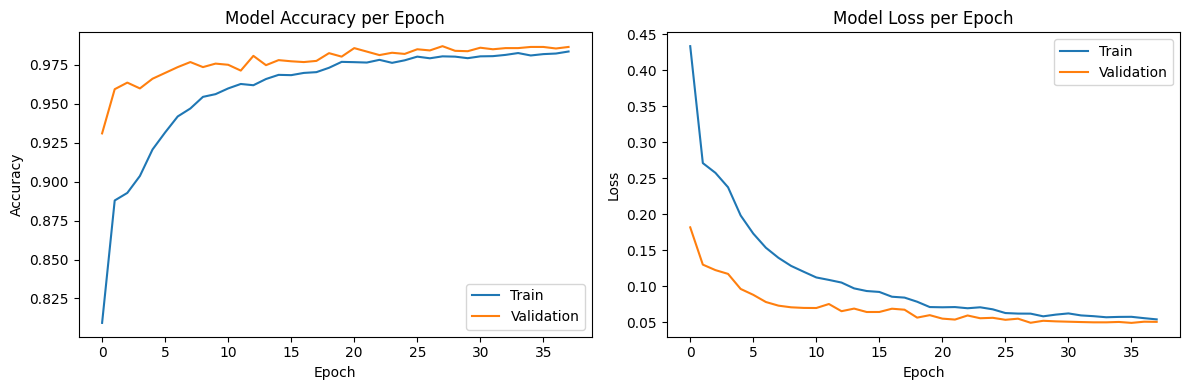

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [12]:
# INFERENCE FUNCTION
_model    = tf.keras.models.load_model('healthy_posture_model.keras')
_scaler   = pickle.load(open('scaler.pkl', 'rb'))
_le_dict  = pickle.load(open('label_encoders.pkl', 'rb'))
_le_target = pickle.load(open('label_encoder_target.pkl', 'rb'))

FEATURE_ORDER = [
    'total_sitting_minutes', 'number_of_breaks', 'avg_break_duration_minutes',
    'longest_sitting_streak_minutes', 'fatigue_level',
    'age', 'daily_work_hours', 'bmi', 'sleep_hours',
    'gender', 'work_type', 'fitness_level',
    'day_of_week', 'time_of_day_dominant', 'device_preference'
]

CAT_COLS = [
    'gender', 'work_type', 'fitness_level',
    'day_of_week', 'time_of_day_dominant', 'device_preference'
]

def predict_risk(
    total_sitting_minutes,
    number_of_breaks,
    avg_break_duration_minutes,
    longest_sitting_streak_minutes,
    fatigue_level,
    age,
    daily_work_hours,
    bmi,
    sleep_hours=7.0,
    gender='Male',
    work_type='Office',
    fitness_level='Medium',
    day_of_week='Monday',
    time_of_day_dominant='Morning',
    device_preference='Laptop'
):
    # 1. Encode kategorikal
    cat_encoded = {}
    for col in CAT_COLS:
        val = locals()[col]
        if val not in _le_dict[col].classes_:
            raise ValueError(
                f'Nilai "{val}" tidak valid untuk {col}. '
                f'Valid: {list(_le_dict[col].classes_)}'
            )
        cat_encoded[col] = int(_le_dict[col].transform([val])[0])

    # 2. Susun DataFrame urutan FEATURE_ORDER
    input_df = pd.DataFrame([{
        'total_sitting_minutes': total_sitting_minutes,
        'number_of_breaks': number_of_breaks,
        'avg_break_duration_minutes': avg_break_duration_minutes,
        'longest_sitting_streak_minutes': longest_sitting_streak_minutes,
        'fatigue_level': fatigue_level,
        'age': age,
        'daily_work_hours': daily_work_hours,
        'bmi': bmi,
        'sleep_hours': sleep_hours,
        'gender': cat_encoded['gender'],
        'work_type': cat_encoded['work_type'],
        'fitness_level':cat_encoded['fitness_level'],
        'day_of_week': cat_encoded['day_of_week'],
        'time_of_day_dominant': cat_encoded['time_of_day_dominant'],
        'device_preference': cat_encoded['device_preference']
    }])[FEATURE_ORDER]

    # 3. Scale
    input_scaled = _scaler.transform(input_df)

    # 4. Prediksi
    proba      = _model.predict(input_scaled, verbose=0)[0]
    labels     = list(_le_target.classes_)
    pred_label = labels[np.argmax(proba)]
    confidence = float(np.max(proba))

    return pred_label, confidence

print("Inference function siap")

Inference function siap


In [13]:
# TEST INFERENCE
label, conf = predict_risk(
    total_sitting_minutes=480,
    number_of_breaks=2,
    avg_break_duration_minutes=3.0,
    longest_sitting_streak_minutes=320,
    fatigue_level=3,
    age=25,
    daily_work_hours=9,
    bmi=24.0,
    sleep_hours=7.0,
    gender='Male',
    work_type='WFH',
    fitness_level='Low',
    day_of_week='Monday',
    time_of_day_dominant='Morning',
    device_preference='Laptop'
)

print(f"Test Inference:")
print(f"  Prediksi   : {label}")
print(f"  Confidence : {conf:.2%}")

Test Inference:
  Prediksi   : Tinggi
  Confidence : 99.82%
